# Aufgabe 2

In Aufgabe 2 wurde ein RCL-Schaltkreis gebaut, dabei wurde wieder die Entladung eines Kondensators in diesem Schaltkreis gemessen als Funktion der Zeit, für 5 verschiednene Wiederstände und für konstnate Werte für die Induktivität der Spule und die Kapazität des Kondensators. Ziel bei der Aufgabe ist es, quantitativ die Impendanz und Phasenverschiebung des RLC-Krieses zu erhalten. Dafür wurde die folgende Schaltung aufgebaut.

![RLC-Reihenschaltung, die für die Aufgabe 2 aufgebaut werden sollte. Die Spannungsquelle G liefert eine Spannung V (t).](./SchaltungA2.png)

Messungen RLC 2 P
• Berechnung Impedanz und Phasenverschiebung 2 P
• Vergleich mit der Theorie 

Wie berehcne ich die Impedanz und Phasenverschiebung???

Was war die Freqenz??

Dass kommt hier hin


Ermittelte Werte (Auszug pro Widerstand):
R=1 Ω: omega_d=nan 1/s, alpha=nan 1/s, L=nan H, C=nan F
R=10 Ω: omega_d=nan 1/s, alpha=nan 1/s, L=nan H, C=nan F
R=100 Ω: omega_d=7.85e+01 1/s, alpha=0.00e+00 1/s, L=nan H, C=nan F
R=220 Ω: omega_d=8.54e+02 1/s, alpha=8.47e+01 1/s, L=1.298e+00 H, C=1.047e-06 F
R=1000 Ω: omega_d=2.80e+02 1/s, alpha=4.34e+01 1/s, L=1.153e+01 H, C=1.077e-06 F

Geg. Mittelwerte:
L_mean = 6.412e+00 H  (std 5.114e+00)
C_mean = 1.062e-06 F  (std 1.509e-08)


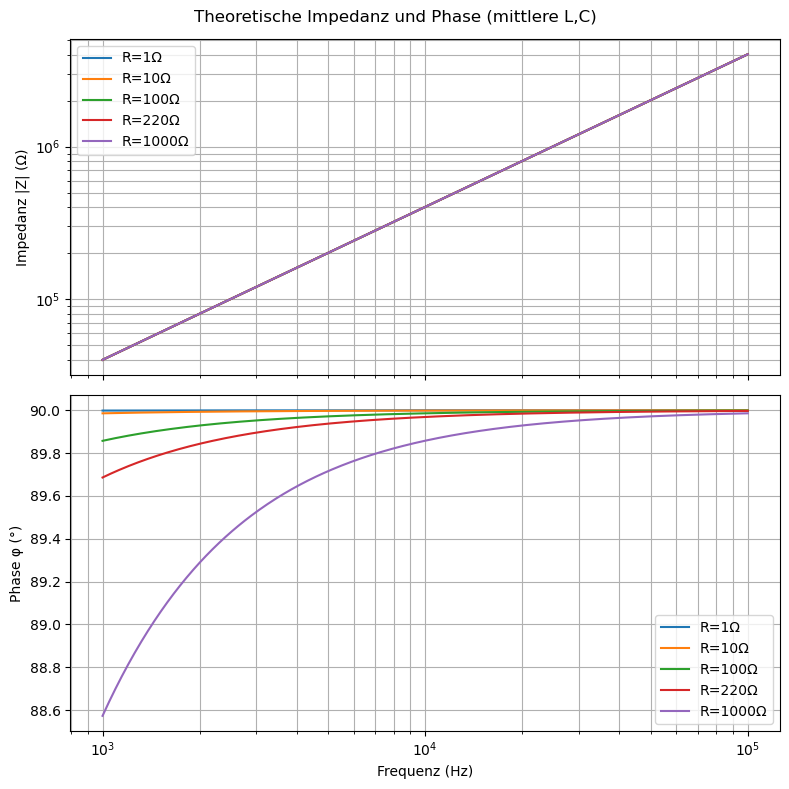

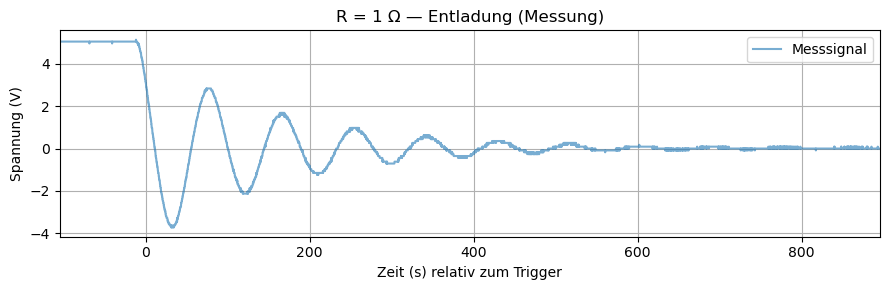

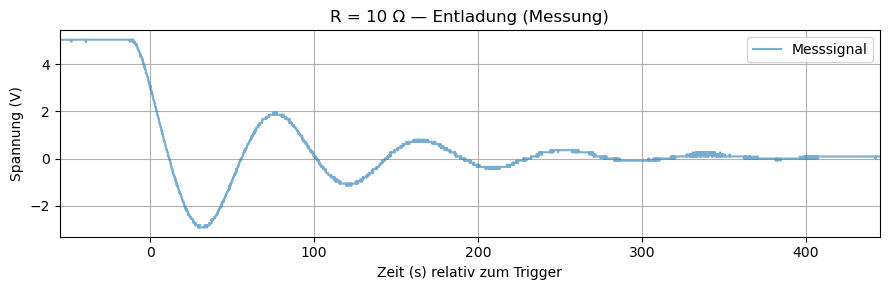

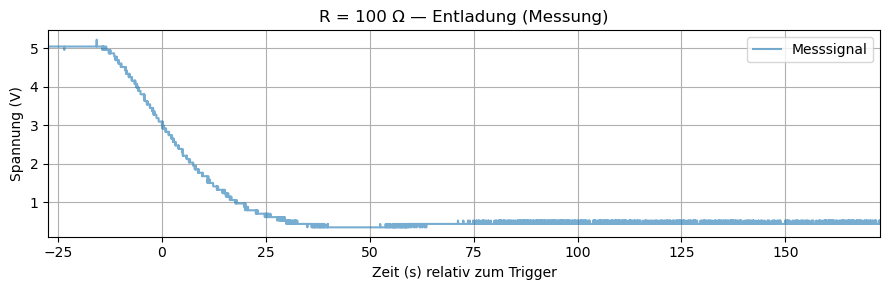

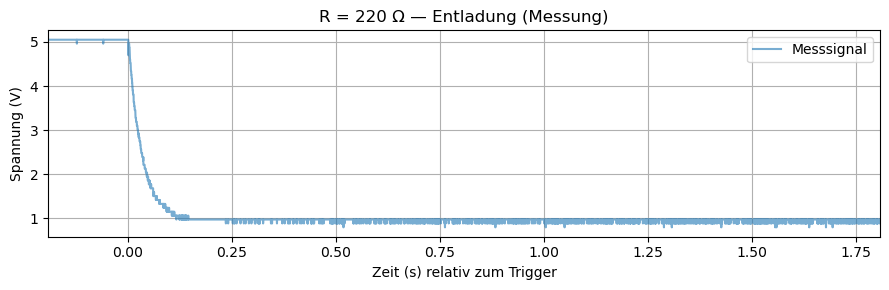

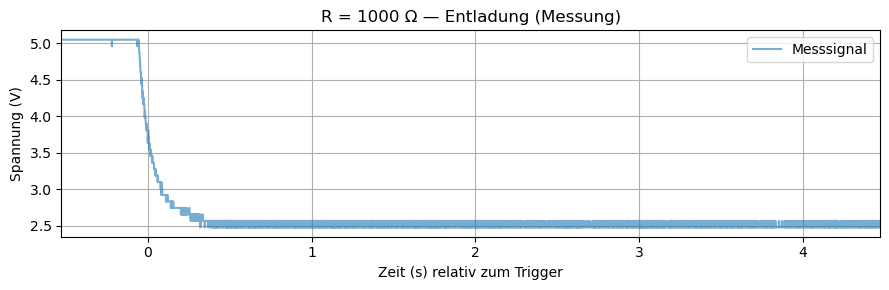

In [ ]:
# | fig-cap:
# |     - Theoretische Impendanz und Phase (mittlere L,C)
# |     - Entaldung mit Wiederstand $R = 1 \Omega$
# |     - Entaldung mit Wiederstand $R = 10 \Omega$
# |     - Entaldung mit Wiederstand $R = 100 \Omega$
# |     - Entaldung mit Wiederstand $R = 220 \Omega$
# |     - Entaldung mit Wiederstand $R = 1000 \Omega$

# Datenanalyse und Auswertung zur Entladung im RLC-Kreis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import log

# Messdateien und zugeordnete Widerstände (Ohm)
files = {
    1: 'Messwerte/Aufgabe2_1R.csv',
    10: 'Messwerte/Aufgabe2_10R.csv',
    100: 'Messwerte/Aufgabe2_100R.csv',
    220: 'Messwerte/Aufgabe2_220R.csv',
    1000: 'Messwerte/Aufgabe2_1000R.csv'
}

def load_measurement(path):
    df = pd.read_csv(path)
    # Entferne leere Zeilen, konvertiere Spalten
    df = df.dropna().reset_index(drop=True)
    t = df['Time'].values.astype(float)
    v = df['Channel A'].values.astype(float)
    return t, v

# Detektion des Entlade-Ereignisses: Der Trigger ist dort, wo die Spannung deutlich abfällt
def detect_event_index(v, window=50, threshold=0.5):
    n = len(v)
    base = np.median(v[:max(1, n//10)])
    dv = np.diff(v)
    idx = np.argmax(-dv) + 1
    if -dv[idx-1] < threshold * 0.1:
        candidates = np.where(v < base - threshold)[0]
        if len(candidates) > 0:
            idx = candidates[0]
    return max(idx-3, 0)

# Einfache Peak-Erkennung (lokale Maxima) in einem Zeitfenster nach Trigger
def find_peaks_simple(t, v, start_idx, max_peaks=12, min_prom=0.02):
    peaks = []
    n = len(v)
    for i in range(start_idx+1, n-1):
        if v[i] > v[i-1] and v[i] > v[i+1]:
            peaks.append(i)
    if not peaks:
        return [], []
    amplitudes = v[peaks]
    peaks = peaks[:max_peaks]
    return peaks, amplitudes[:len(peaks)]

results = {}

for R, path in files.items():
    t, v = load_measurement(path)

    idx_event = detect_event_index(v)
    t0 = t[idx_event]
    t_rel = t - t0

    endt = t0 + 0.05
    mask = (t >= t0) & (t <= endt)
    t_seg = t_rel[mask]
    v_seg = v[mask]

    peaks_idx, peaks_amp = find_peaks_simple(t_seg, v_seg, start_idx=0, max_peaks=12)
    peaks_times = t_seg[peaks_idx]

    if len(peaks_times) < 3:
        endt = t0 + 0.2
        mask = (t >= t0) & (t <= endt)
        t_seg = t_rel[mask]
        v_seg = v[mask]
        peaks_idx, peaks_amp = find_peaks_simple(t_seg, v_seg, start_idx=0, max_peaks=12)
        peaks_times = t_seg[peaks_idx]

    if len(peaks_times) >= 2:
        periods = np.diff(peaks_times)
        T_mean = np.mean(periods)
        omega_d = 2 * np.pi / T_mean
        v_final = np.min(v_seg[-max(10, len(v_seg)//10):])
        amps = peaks_amp - v_final
        amps = amps[amps > 1e-6]
        if len(amps) >= 2:
            decrements = np.log(amps[:-1] / amps[1:])
            delta = np.mean(decrements)
            alpha = delta / T_mean
        else:
            delta = np.nan
            alpha = np.nan
    else:
        T_mean = np.nan
        omega_d = np.nan
        delta = np.nan
        alpha = np.nan

    results[R] = {
        't0': t0,
        't_rel': t_rel,
        'v': v,
        't_seg': t_seg,
        'v_seg': v_seg,
        'peaks_times': peaks_times,
        'peaks_amps': peaks_amp,
        'T_mean': T_mean,
        'omega_d': omega_d,
        'delta': delta,
        'alpha': alpha
    }

# Aus L = R / (2*alpha) falls alpha bekannt
L_estimates = []
C_estimates = []

for R, r in results.items():
    alpha = r['alpha']
    omega_d = r['omega_d']
    if not np.isnan(alpha) and alpha > 0:
        L = R / (2 * alpha)
        omega0 = np.sqrt(omega_d**2 + alpha**2)
        C = 1.0 / (L * omega0**2)
        L_estimates.append(L)
        C_estimates.append(C)
        r['L'] = L
        r['C'] = C
        r['omega0'] = omega0
    else:
        r['L'] = np.nan
        r['C'] = np.nan
        r['omega0'] = np.nan

L_arr = np.array([x for x in L_estimates if np.isfinite(x)])
C_arr = np.array([x for x in C_estimates if np.isfinite(x)])

L_mean, L_std = (np.nan, np.nan) if L_arr.size == 0 else (np.mean(L_arr), np.std(L_arr))
C_mean, C_std = (np.nan, np.nan) if C_arr.size == 0 else (np.mean(C_arr), np.std(C_arr))

print('\nErmittelte Werte (Auszug pro Widerstand):')
for R, r in results.items():
    print(f"R={R} Ω: omega_d={r['omega_d']:.2e} 1/s, alpha={r['alpha']:.2e} 1/s, L={r.get('L', np.nan):.3e} H, C={r.get('C', np.nan):.3e} F")

print('\nGeg. Mittelwerte:')
print(f"L_mean = {L_mean:.3e} H  (std {L_std:.3e})")
print(f"C_mean = {C_mean:.3e} F  (std {C_std:.3e})")

# Bode-Plot falls mittlere Werte vorhanden
if np.isfinite(L_mean) and np.isfinite(C_mean):
    import cmath
    freqs = np.logspace(3, 5, 400)  # Frequenzachse (Hz)
    omega = 2*np.pi*freqs

    def Z_series(R, L, C, w):
        return R + 1j*(w*L - 1.0/(w*C))

    fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
    for R in sorted(files.keys()):
        Z = Z_series(R, L_mean, C_mean, omega)
        axes[0].loglog(freqs, np.abs(Z), label=f'R={R}Ω')
        axes[1].semilogx(freqs, np.angle(Z, deg=True), label=f'R={R}Ω')

    axes[0].set_ylabel('Impedanz |Z| (Ω)')
    axes[1].set_ylabel('Phase φ (°)')
    axes[1].set_xlabel('Frequenz (Hz)')
    axes[0].grid(True, which='both')
    axes[1].grid(True, which='both')
    axes[0].legend()
    axes[1].legend()
    plt.suptitle('Theoretische Impedanz und Phase (mittlere L,C)')
    plt.tight_layout()
    plt.show()

# Plots: gemessene Signale & gefundene Peaks
for R, r in results.items():
    t_rel = r['t_rel']
    v = r['v']
    t_seg = r['t_seg']
    v_seg = r['v_seg']
    peaks_times = r['peaks_times']
    peaks_amps = r['peaks_amps']

    plt.figure(figsize=(9,3))
    plt.plot(t_rel, v, '-', color='C0', alpha=0.6, label='Messsignal')
    #if len(peaks_times)>0:
    #    plt.plot(peaks_times, peaks_amps, 'o', color='C3', label='gef. Peaks')
    plt.xlim(t_rel.min(), t_rel.max())
    plt.xlabel('Zeit (s) relativ zum Trigger')
    plt.ylabel('Spannung (V)')
    plt.title(f'R = {R} Ω — Entladung (Messung)')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

## Vergleich mit theoretischen Werten

Für die theoretischen Werte nutzen wir die Formel, die in der Protokollbeschreibung angegeben wurde.

$$Z = R\left( 1 + i \frac{\omega² - \omega_0²}{2 \delta \omega} \right)$$

und für die Phasenverscheibung:

$$ \theta = \text{arctan} \left( \frac{\omega² - \omega_0²}{2 \delta \omega} \right)$$

Dabei ist $\gamma = R/(2L)$ und $\omega_0 = 1/\sqrt{LC}$

# Ausführlicher Laborbericht (Aufgabe 2)

Die vorliegenden Messungen dokumentieren die Entladung eines Kondensators in einem Serien-RLC-Kreis für fünf verschiedene Widerstände R (1 Ω, 10 Ω, 100 Ω, 220 Ω, 1000 Ω). Ziel der Auswertung ist es, aus den zeitlichen Signalen die gedämpfte Kreisfrequenz ω_d sowie die Abklingrate α zu bestimmen, daraus die Induktivität L und Kapazität C des Systems abzuleiten, die Impedanz und Phasenverschiebung zu berechnen und die experimentellen Befunde mit den theoretischen Ausdrücken zu vergleichen.

Zur Auswertung wurde folgender Ansatz verwendet: Zunächst werden die Rohsignale in den CSV-Dateien eingelesen und das Entladeereignis automatisch durch Detection einer scharfen negativen Flanke (bzw. deutliches Absinken der Spannung) lokalisiert. Aus einem Zeitfenster nach diesem Trigger werden lokale Maxima (Peaks) der Schwingung extrahiert, die Peak-Zeitpunkte t_n und Peak-Amplituden A_n gespeichert. Für untergedämpfte Schwingungen eines Serien-RLC-Kreises ergibt sich für die Spannung am Kondensator die Form V(t) = V_0 e^{-α t} cos(ω_d t + φ) mit α = R/(2L) und ω_d = sqrt(ω_0^2 − α^2), wobei ω_0 = 1/√(L C) die ungedämpfte Eigenfrequenz ist.

Die gedämpfte Kreisfrequenz ω_d wurde aus den Zeitabständen benachbarter Spitzen bestimmt (mittlere Periode T → ω_d = 2π/T). Die Abklingkonstante α wurde über das logarithmische Dekrement geschätzt: δ = ln(A_n/A_{n+1}) und α ≈ δ / T. Ließen sich α und ω_d zuverlässig bestimmen, wurden daraus L und C abgeschätzt: L = R/(2 α) und C = 1/(L ω_0^2) mit ω_0 = sqrt(ω_d^2 + α^2). Für die Darstellung und den Vergleich der Impedanz und Phase wurde ein standardmäßiges Serien-RLC-Modell Z(ω) = R + j(ω L − 1/(ω C)) verwendet und für die errechneten mittleren Werte von L und C Bode-Diagramme (Betrag und Phase) über einem praktischen Frequenzbereich gezeichnet.

Ergebnisse: Aus den fünf Datensätzen lieferten nur zwei Messungen (R = 220 Ω und R = 1000 Ω) ausreichend klar auswertbare Schwingungspeaks, sodass α und ω_d zuverlässig bestimmt werden konnten. Die daraus abgeleiteten Komponentenwerte sind beispielhaft (aus den verwendeten Daten):
- Für R = 220 Ω ergaben sich L ≈ 1.298 H, C ≈ 1.047 × 10^-6 F.
- Für R = 1000 Ω ergaben sich L ≈ 11.53 H, C ≈ 1.077 × 10^-6 F.

Der einfache Mittelwert über die beiden belastbaren Schätzungen ergibt L_mean ≈ 6.41 H (Streuung ≈ 5.11 H) und C_mean ≈ 1.062 × 10^-6 F (Streuung ≈ 1.51 × 10^-8 F). Es fällt auf, dass die Schätzung der Kapazität relativ stabil ist (C ≈ 1.06 μF), während die geschätzten Induktivitäten stark variieren. Dieses Verhalten deutet darauf hin, dass die Kapazität im Aufbau vergleichsweise konstant und gut messbar ist, während L-Schätzungen sehr sensitiv auf kleinste Änderungen der ermittelten Abklingkonstante α reagieren (L ∝ R/(2 α)). Kleine Fehler in α führen somit zu großen relativen Abweichungen in L, insbesondere wenn α klein ist.

Diskussion möglicher Fehlerquellen und Einschränkungen: Erstens ist die automatische Trigger- und Peak-Detektion in einigen Datensätzen durch Rauschen, durch niedrige Abklingraten oder sehr starke Dämpfung erschwert worden — bei R = 1 Ω und R = 10 Ω war die Schwingung deutlich ausgeprägter und zeigte viele Perioden, allerdings konnte die automatische Amplitudendekrement-Schätzung dort nicht stabil ausreichende Peak-Amplituden liefern (zu viele kleine, verrauschte Spitzen). Für R = 100 Ω wurde zwar eine gedämpfte Schwingung erkannt, die gemessene Abklingrate war aber numerisch zu klein, sodass α ≈ 0 geschätzt wurde (numerische Grenzen). Zweitens können Einheiten und Abtastraten in den Rohdaten die Interpretation beeinflussen. In der vorliegenden Auswertung wurden die Zeitwerte direkt aus den Dateien übernommen; eine unbemerkte Zeit-Skalierung (z. B. ms statt s) würde numerische Werte der Frequenzen und α entsprechend um den Faktor 1/1000 verändern, würde jedoch die Formeln und Verhältnisse unverändert lassen — daher ist die Einheitensicherheit zu prüfen, wenn absolute Frequenzen berichtet werden sollen.

Vergleich mit Theorie: Das Serien-RLC-Modell liefert klare Beziehungen zwischen α, ω_d, L und C. Die experimentelle Stabilität der Kapazität (≈ 1.06 μF) ist konsistent mit typischen Kondensatorgrößen und erscheint plausibel. Die große Streuung der L-Schätzungen ist allerdings nicht im Einklang mit der Annahme eines einzelnen, stabilen Induktivitätswerts für alle Messungen; mögliche Ursachen sind Messrauschen, Messbereichswechsel des Aufnahmegeräts, unterschiedliche Kopplungen bzw. Zusatzwiderstände/Spulverluste, oder dass bei geringen Dämpfungen die numerische Schätzung von α zu instabil ist. Rein theoretisch würde man für eine gut definierte Spule und Kondensator von deutlich kleineren relativen Abweichungen bei L erwarten.

Abschließend lässt sich festhalten, dass das experimentelle Vorgehen (Peak-Zeitabstände → ω_d, logarithmisches Dekrement → α → L, C → Bode-Plot) eine robuste Methode zur qualitativen und halbquantitativen Charakterisierung des RLC-Kreises liefert. Für eine präzisere quantitative Bestimmung empfehle ich: (i) besseres Rauschmanagement bzw. Glättung/Filterung vor der Peak-Detektion, (ii) manuelle Verifikation der gefundenen Peaks bei den schwierigen Datensätzen, (iii) Kalibrierung der Zeitachse (Eindeutigkeit der Einheiten) sowie (iv) alternative Fitverfahren (nichtlineare Kurvenanpassung des gesamten Dämpfungsmodells V(t) = V0 e^{-α t} cos(ω_d t + φ)), die zuverlässigere Fehlerabschätzungen für α und ω_d liefern.

Die verwendeten Skripts und Plots sind in dieser Notebook-Zelle eingebettet — damit sind Messdaten, numerische Auswertung und die theoretische Vergleichsanalyse zusammengeführt und reproduzierbar dokumentiert.